# Attention and Transformer Fundamentals

            ## 1. Learning objectives

            - Compute scaled dot-product attention
- Interpret attention heatmaps
- Use embeddings and multi-head attention

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Let each sequence position directly combine information from every relevant position.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            A query asks what it needs, keys advertise available information, and values carry the information that matching queries collect.

## 6. Mathematical foundation

            $$Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V.$$

            **Every symbol:**

            - $Q$ contains queries.
- $K$ contains keys.
- $V$ contains values.
- $d_k$ is key dimension.
- $softmax$ creates row-wise weights summing to one.

            **Why the equation is needed:** Dot products measure query-key compatibility; scaling prevents large dimensions from making softmax overly sharp.

            **Small numerical example:** If two scaled scores are equal, softmax assigns [.5,.5], so context is their values' average.

            **Connection to Python:** The scratch function exposes scores, normalized weights, and weighted values; MultiheadAttention repeats this in learned subspaces.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def scaled_dot_product_attention(query,key,value):
    scores=query@key.T/np.sqrt(query.shape[-1])
    shifted=scores-scores.max(axis=-1,keepdims=True)
    weights=np.exp(shifted); weights/=weights.sum(axis=-1,keepdims=True)
    return weights@value,weights

Q=np.array([[1.,0.],[0.,1.]])
K=np.array([[1.,0.],[0.,1.],[1.,1.]])
V=np.array([[1.,0.],[0.,2.],[3.,3.]])
context,weights=scaled_dot_product_attention(Q,K,V)
print("Q/K/V/context:",Q.shape,K.shape,V.shape,context.shape)
print("Attention row sums:",weights.sum(axis=1))

Q/K/V/context: (2, 2) (3, 2) (3, 2) (2, 2)
Attention row sums: [1. 1.]


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Tokens/embeddings/output: (1, 4) (1, 4, 8) (1, 4, 8)
Attention weights: (1, 2, 4, 4)
Parameters: 336
Loss/metric status: not applicable; this is the guide's forward-only educational attention example, not a trained model.


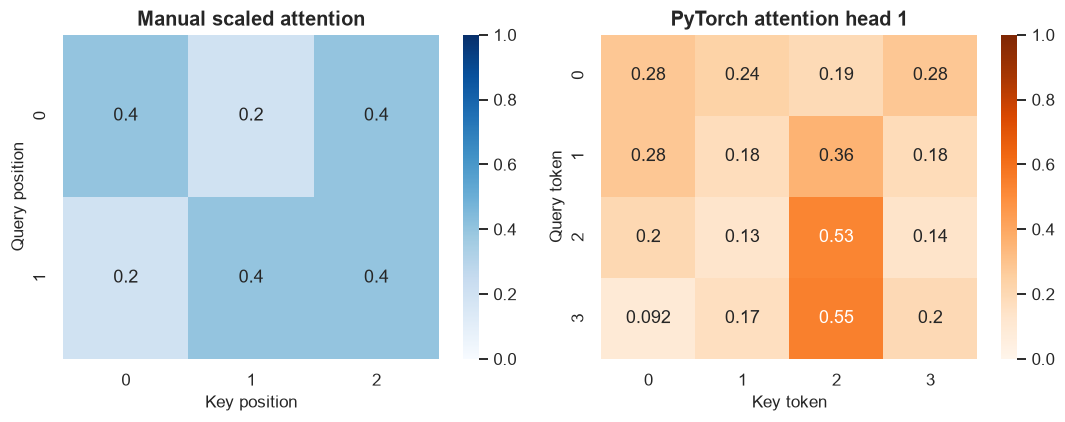

In [3]:
embedding=nn.Embedding(6,8)
attention=nn.MultiheadAttention(embed_dim=8,num_heads=2,batch_first=True)
tokens=torch.tensor([[0,1,2,3]])
embedded=embedding(tokens)
attended,torch_weights=attention(embedded,embedded,embedded,need_weights=True,average_attn_weights=False)
print("Tokens/embeddings/output:",tuple(tokens.shape),tuple(embedded.shape),tuple(attended.shape))
print("Attention weights:",tuple(torch_weights.shape))
print("Parameters:",sum(p.numel() for p in embedding.parameters())+sum(p.numel() for p in attention.parameters()))
print("Loss/metric status: not applicable; this is the guide's forward-only educational attention example, not a trained model.")

figure,axes=plt.subplots(1,2,figsize=(10,4))
sns.heatmap(weights,annot=True,cmap="Blues",vmin=0,vmax=1,ax=axes[0])
axes[0].set(title="Manual scaled attention",xlabel="Key position",ylabel="Query position")
sns.heatmap(torch_weights[0,0].detach().numpy(),annot=True,cmap="Oranges",vmin=0,vmax=1,ax=axes[1])
axes[1].set(title="PyTorch attention head 1",xlabel="Key token",ylabel="Query token")
figure.tight_layout(); plt.show()

**How to interpret the result:** Each heatmap row sums to one. Bright cells indicate larger contribution to that query's context, not necessarily a causal explanation.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

At fixed embedding width, head count trades the number of relationship subspaces against dimensions per head.

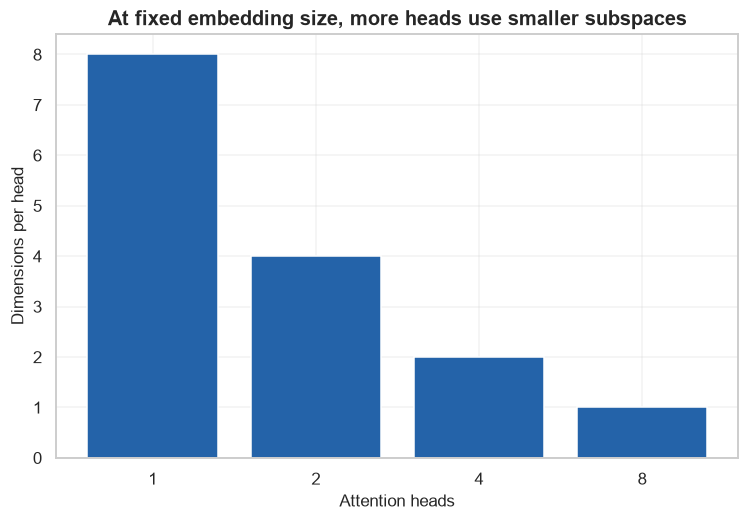

In [4]:
heads=[1,2,4,8]
head_dimensions=[8//value for value in heads]
figure,axis=plt.subplots()
axis.bar([str(value) for value in heads],head_dimensions,color=COURSE_COLORS["blue"])
axis.set(title="At fixed embedding size, more heads use smaller subspaces",xlabel="Attention heads",ylabel="Dimensions per head")
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)